In [4]:
import os
import ast
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [5]:
# Define base path
path = "ptb-xl-1.0.3/"

# Load PTB-XL metadata
Y = pd.read_csv(os.path.join(path, "ptbxl_database.csv"), index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load SCP statements for grouping
agg_df = pd.read_csv(os.path.join(path, "scp_statements.csv"), index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

In [6]:
def aggregate_diagnostic(y_dic):
    return list({agg_df.loc[k].diagnostic_class for k in y_dic if k in agg_df.index})

Y["diagnostic_superclass"] = Y.scp_codes.apply(aggregate_diagnostic)

In [ ]:
def filter_data(row):
    ds = row["diagnostic_superclass"]
    if len(ds) == 0:
        return False
    if "NORM" in ds and len(ds) > 1:
        return False
    if "STTC" in ds and len(ds) == 1:
        return False
    return True

Y = Y[Y.apply(filter_data, axis=1)]
Y["is_normal"] = Y.diagnostic_superclass.apply(lambda x: "NORM" in x)


In [24]:
def load_raw_data(df, path):
    data = [wfdb.rdsamp(os.path.join(path, f))[0] for f in df.filename_hr]
    return np.array(data)

# Optional: only take a subset for testing (faster)
Y_short = Y.head(1000)
X = load_raw_data(Y_short, path)
y_data = Y_short['is_normal'].astype(int).values  # 1 = normal, 0 = abnormal

In [25]:
X.shape

(1000, 5000, 12)

In [10]:
# Flatten each 12-lead ECG to 1D vector
X_flat = X.reshape((X.shape[0], -1))

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

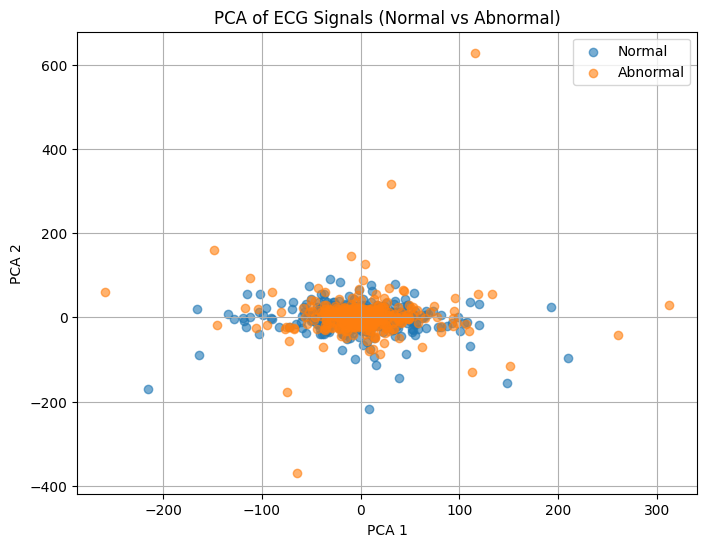

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

labels = Y_short["is_normal"].values
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[labels == True, 0], X_pca[labels == True, 1], alpha=0.6, label="Normal")
plt.scatter(X_pca[labels == False, 0], X_pca[labels == False, 1], alpha=0.6, label="Abnormal")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.title("PCA of ECG Signals (Normal vs Abnormal)")
plt.grid(True)
plt.show()

In [12]:
pca = PCA(n_components=20)
pca.fit(X_flat)
print(pca.explained_variance_ratio_)

[0.02688095 0.02081381 0.01722516 0.01615493 0.01433707 0.01409592
 0.013938   0.01268074 0.0122609  0.01174128 0.01082613 0.01040164
 0.00961081 0.00909554 0.00893725 0.00829167 0.00809109 0.00783003
 0.00710552 0.00679025]


In [ ]:
import umap.umap_ as umap
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_flat)




/opt/anaconda3/envs/qae-ecg/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  
/opt/anaconda3/envs/qae-ecg/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


NameError: name 'sns' is not defined

In [19]:
y_data = Y_short['is_normal'].values.astype(int)  # 1 for normal, 0 for abnormal

<Axes: >

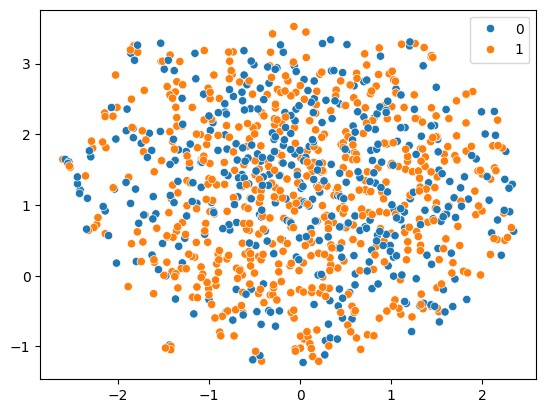

In [20]:
import seaborn as sns

sns.scatterplot(x=X_umap[:,0], y=X_umap[:,1], hue=y_data)

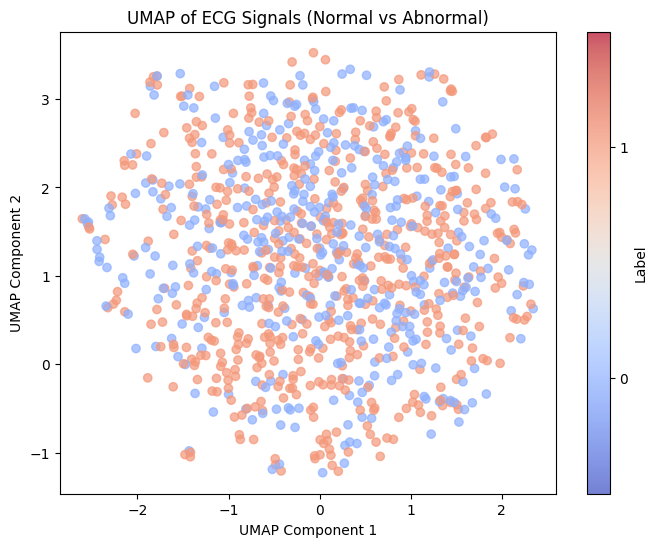

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_data, cmap="coolwarm", alpha=0.7)
plt.title("UMAP of ECG Signals (Normal vs Abnormal)")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.colorbar(scatter, ticks=[0, 1], label='Label')
plt.clim(-0.5, 1.5)
plt.show()

In [22]:
X_flat = X_umap  # or X_pca depending on the method used
y_labels = Y_short['is_normal'].astype(int).values 

In [29]:
import wfdb
import os
import numpy as np
import pandas as pd
import ast

# Load the annotation file
Y = pd.read_csv('ptb-xl-1.0.3/ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(ast.literal_eval)

# Load diagnostic codes
agg_df = pd.read_csv('ptb-xl-1.0.3/scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dic):
    return list(set(
        agg_df.loc[key].diagnostic_class for key in y_dic if key in agg_df.index
    ))

Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

# Filter rows
def filter_data(row):
    ds = row['diagnostic_superclass']
    if len(ds) == 0: return False
    if 'NORM' in ds and len(ds) > 1: return False
    if 'STTC' in ds and len(ds) == 1: return False
    return True

Y = Y[Y.apply(filter_data, axis=1)]
Y['is_normal'] = Y.diagnostic_superclass.apply(lambda x: 'NORM' in x)

# Limit to 1000 samples
Y_short = Y.head(1000)

# Load raw waveform data
def load_raw_data(df, path):
    return np.array([
        wfdb.rdsamp(os.path.join(path, f))[0] for f in df.filename_hr
    ])

X = load_raw_data(Y_short, 'ptb-xl-1.0.3/')
y_data = Y_short['is_normal'].values.astype(int)

In [31]:
# Assume X.shape = (1000, 5000, 12)
# Step 1: Extract Lead II (index 1)
X_lead = X[:, :, 1]  # shape = (1000, 5000)

# Step 2: Downsample to 1000 timepoints (keep only first second if 500Hz)
X_ds = X_lead[:, :1000]  # shape = (1000, 1000)

# Step 3: Normalize each trace individually
X_norm = (X_ds - X_ds.mean(axis=1, keepdims=True)) / (X_ds.std(axis=1, keepdims=True) + 1e-8)

# Step 4: Flatten
X_flat = X_norm.reshape((X_norm.shape[0], -1))  # shape = (1000, 1000)

# Labels
y_labels = Y_short['is_normal'].values.astype(int)

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Split
X_train, X_test, y_train, y_test = train_test_split(X_flat, y_labels, test_size=0.2, stratify=y_labels, random_state=42)

# Train
svm = SVC(kernel='rbf', C=1.0, gamma='scale')
svm.fit(X_train, y_train)

# Predict
y_pred = svm.predict(X_test)

# Evaluate
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=["abnormal", "normal"]))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

    abnormal       0.54      0.17      0.26        81
      normal       0.61      0.90      0.73       119

    accuracy                           0.60       200
   macro avg       0.58      0.54      0.50       200
weighted avg       0.58      0.60      0.54       200

Confusion Matrix:
 [[ 14  67]
 [ 12 107]]


In [2]:
import os
import ast
import numpy as np
import pandas as pd
import wfdb
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Path to your PTB-XL dataset
data_path = 'ptb-xl-1.0.3/'  # ← Set this ONCE

# Load metadata
df = pd.read_csv(os.path.join(data_path, 'ptbxl_database.csv'), index_col='ecg_id')
df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load SCP statements and filter for diagnostic classes
scp_df = pd.read_csv(os.path.join(data_path, 'scp_statements.csv'), index_col=0)
scp_diagnostic = scp_df[scp_df.diagnostic == 1]

# Map scp codes to diagnostic superclasses
def aggregate_diagnostic(y_dict):
    return list(set(
        scp_diagnostic.loc[key].diagnostic_class
        for key in y_dict.keys()
        if key in scp_diagnostic.index
    ))

df["diagnostic_superclass"] = df.scp_codes.apply(aggregate_diagnostic)

# Filter: keep clean normal or clearly abnormal cases (exclude STTC-only)
def filter_data(row):
    classes = row["diagnostic_superclass"]
    if not classes:
        return False
    if "NORM" in classes and len(classes) > 1:
        return False
    if "STTC" in classes and len(classes) == 1:
        return False
    return True

df = df[df.apply(filter_data, axis=1)]
df["is_normal"] = df["diagnostic_superclass"].apply(lambda x: "NORM" in x)

# Limit to smaller dataset for testing
df_short = df.head(1000)

# Load waveform data
def load_raw_data(df_subset, path):
    return np.array([
        wfdb.rdsamp(os.path.join(path, fname))[0]
        for fname in df_subset["filename_hr"]
    ])

X_raw = load_raw_data(df_short, data_path)  # shape: (N, 5000, 12)

# Extract 72 features (mean, std, min, max, median, peak-to-peak) per lead
def extract_features(X):
    means = X.mean(axis=1)
    stds = X.std(axis=1)
    mins = X.min(axis=1)
    maxs = X.max(axis=1)
    medians = np.median(X, axis=1)
    p2p = np.ptp(X, axis=1)  # fixed here

    return np.concatenate([means, stds, mins, maxs, medians, p2p], axis=1)

X_feat = extract_features(X_raw)
y = df_short["is_normal"].astype(int).values

# Train/test split
X_train, X_val, y_train, y_val = train_test_split(
    X_feat, y, test_size=0.2, random_state=42, stratify=y
)

# Train SVM
clf = SVC(kernel="rbf", probability=True)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_val)
print("Classification Report:\n", classification_report(y_val, y_pred, target_names=["abnormal", "normal"]))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))

Classification Report:
               precision    recall  f1-score   support

    abnormal       0.84      0.65      0.74        81
      normal       0.80      0.92      0.85       119

    accuracy                           0.81       200
   macro avg       0.82      0.79      0.79       200
weighted avg       0.81      0.81      0.80       200

Confusion Matrix:
 [[ 53  28]
 [ 10 109]]


In [ ]:
import time
import numpy as np
import pennylane as qml
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from collections import Counter
from tqdm import tqdm

# Define the quantum kernel
def angle_embedding(x, wires):
    for i in range(len(x)):
        qml.RY(x[i], wires=wires[i])

def quantum_kernel(x1, x2, wires):
    angle_embedding(x1, wires)
    qml.adjoint(angle_embedding)(x2, wires)
    return qml.probs(wires=wires)

class QuantumKernel:
    def __init__(self, n_qubits):
        self.n_qubits = n_qubits
        self.dev = qml.device("default.qubit", wires=n_qubits)
        self.wires = list(range(n_qubits))
        self.qnode = qml.QNode(lambda x1, x2: quantum_kernel(x1, x2, self.wires), self.dev)

    def __call__(self, X1, X2):
        N1, N2 = X1.shape[0], X2.shape[0]
        K = np.zeros((N1, N2))
        for i in range(N1):
            for j in range(N2):
                probs = self.qnode(X1[i], X2[j])
                K[i, j] = probs[0]  # all-zero state probability
        return K

# Normalize first 6 features to [0, π]
def prepare_quantum_features(X_train, X_val, n_qubits=6):
    scaler = MinMaxScaler((0, np.pi))
    X_combined = np.vstack((X_train[:, :n_qubits], X_val[:, :n_qubits]))
    scaler.fit(X_combined)
    X_train_scaled = scaler.transform(X_train[:, :n_qubits])
    X_val_scaled = scaler.transform(X_val[:, :n_qubits])
    return X_train_scaled, X_val_scaled

# ---- QUANTUM RUN ----
n_qubits = 6
X_train_q, X_val_q = prepare_quantum_features(X_train, X_val, n_qubits=n_qubits)

qkernel = QuantumKernel(n_qubits=n_qubits)

start_time = time.time()
K_train = qkernel(X_train_q, X_train_q)
K_val = qkernel(X_val_q, X_train_q)
clf_q = SVC(kernel='precomputed')
clf_q.fit(K_train, y_train)
elapsed_time = time.time() - start_time

# Evaluate
y_pred_q = clf_q.predict(K_val)
print("Quantum SVM Classification Report:\n", classification_report(y_val, y_pred_q, target_names=["abnormal", "normal"]))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_q))
print(f"⏱️ Total training + inference time: {elapsed_time:.2f} seconds")

KeyboardInterrupt: 

In [40]:
import os
import time
import ast
import numpy as np
import pandas as pd
import wfdb
from tqdm import tqdm
from collections import Counter
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pennylane as qml

# Set path once
data_path = 'ptb-xl-1.0.3/'

# Load metadata
df = pd.read_csv(os.path.join(data_path, 'ptbxl_database.csv'), index_col='ecg_id')
df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))
scp_df = pd.read_csv(os.path.join(data_path, 'scp_statements.csv'), index_col=0)
scp_diagnostic = scp_df[scp_df.diagnostic == 1]

# Map diagnostic superclass
def aggregate_diagnostic(y_dict):
    return list(set(
        scp_diagnostic.loc[key].diagnostic_class
        for key in y_dict.keys()
        if key in scp_diagnostic.index
    ))

df["diagnostic_superclass"] = df.scp_codes.apply(aggregate_diagnostic)

def filter_data(row):
    classes = row["diagnostic_superclass"]
    if not classes:
        return False
    if "NORM" in classes and len(classes) > 1:
        return False
    if "STTC" in classes and len(classes) == 1:
        return False
    return True

df = df[df.apply(filter_data, axis=1)]
df["is_normal"] = df["diagnostic_superclass"].apply(lambda x: "NORM" in x)

# Use a smaller subset for fast testing
df_short = df.head(1000)

# Load waveform data
def load_raw_data(df_subset, path):
    return np.array([
        wfdb.rdsamp(os.path.join(path, fname))[0]
        for fname in df_subset["filename_hr"]
    ])

X_raw = load_raw_data(df_short, data_path)  # (N, 5000, 12)
y = df_short["is_normal"].astype(int).values

# Feature engineering: 6 stats × 12 leads = 72 features
def extract_features(X):
    means = X.mean(axis=1)
    stds = X.std(axis=1)
    mins = X.min(axis=1)
    maxs = X.max(axis=1)
    medians = np.median(X, axis=1)
    p2p = np.ptp(X, axis=1)  # Updated for NumPy 2.0+
    return np.concatenate([means, stds, mins, maxs, medians, p2p], axis=1)

X_feat = extract_features(X_raw)

# Train/test split
X_train, X_val, y_train, y_val = train_test_split(
    X_feat, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize first n_qubits features to [0, π]
def prepare_quantum_features(X_train, X_val, n_qubits=6):
    scaler = MinMaxScaler((0, np.pi))
    X_combined = np.vstack((X_train[:, :n_qubits], X_val[:, :n_qubits]))
    scaler.fit(X_combined)
    return scaler.transform(X_train[:, :n_qubits]), scaler.transform(X_val[:, :n_qubits])

# Define embedding + kernel circuit
def angle_embedding(x, wires):
    for i in range(len(x)):
        qml.RY(x[i], wires=wires[i])

class ApproximateQuantumKernel:
    def __init__(self, n_qubits, shots=200):
        self.n_qubits = n_qubits
        self.shots = shots
        self.wires = list(range(n_qubits))
        self.dev = qml.device("default.qubit", wires=n_qubits, shots=shots)

        @qml.qnode(self.dev)
        def circuit(x):
            angle_embedding(x, self.wires)
            # Simple entanglement: linear chain of CNOTs
            for i in range(len(self.wires) - 1):
                qml.CNOT(wires=[self.wires[i], self.wires[i + 1]])
            return qml.sample()

        self.circuit = circuit

    def _get_counts(self, x):
        samples = self.circuit(x)
        bitstrings = [''.join(str(b) for b in s) for s in samples]
        return Counter(bitstrings)

    def _estimate_kernel_entry(self, x1, x2):
        c1 = self._get_counts(x1)
        c2 = self._get_counts(x2)
        norm1 = sum(c1.values())
        norm2 = sum(c2.values())
        keys = set(c1) | set(c2)
        return sum((c1.get(k, 0)/norm1) * (c2.get(k, 0)/norm2) for k in keys)

    def __call__(self, X1, X2):
        N1, N2 = X1.shape[0], X2.shape[0]
        K = np.zeros((N1, N2))
        for i in tqdm(range(N1), desc="Computing kernel matrix"):
            for j in range(N2):
                K[i, j] = self._estimate_kernel_entry(X1[i], X2[j])
        return K

# Run Quantum SVM
n_qubits = 6
X_train_q, X_val_q = prepare_quantum_features(X_train, X_val, n_qubits)
qkernel = ApproximateQuantumKernel(n_qubits=n_qubits, shots=200)

start_time = time.time()
K_train = qkernel(X_train_q, X_train_q)
K_val = qkernel(X_val_q, X_train_q)

clf_q = SVC(kernel='precomputed')
clf_q.fit(K_train, y_train)
elapsed_time = time.time() - start_time

# Evaluate
y_pred_q = clf_q.predict(K_val)
print("\nQuantum SVM Classification Report:\n", classification_report(y_val, y_pred_q, target_names=["abnormal", "normal"]))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_q))
print(f"⏱️ Total training + inference time: {elapsed_time:.2f} seconds")

Computing kernel matrix:  17%|█▋        | 133/800 [09:29<47:33,  4.28s/it] 


KeyboardInterrupt: 

In [41]:
# Limit training set size
n_train_samples = 300
X_train_small = X_train_q[:n_train_samples]
y_train_small = y_train[:n_train_samples]

# Recompute kernel matrices (QUANTUM!)
K_train_small = qkernel(X_train_small, X_train_small)
K_val_small = qkernel(X_val_q, X_train_small)

# Train and evaluate QSVM
clf_q_small = SVC(kernel='precomputed')
clf_q_small.fit(K_train_small, y_train_small)
y_pred_q_small = clf_q_small.predict(K_val_small)

# Metrics
print("Quantum SVM (Trimmed) Report:\n", classification_report(y_val, y_pred_q_small, target_names=["abnormal", "normal"]))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_q_small))

Computing kernel matrix: 100%|██████████| 200/200 [05:25<00:00,  1.63s/it]

Quantum SVM (Trimmed) Report:
               precision    recall  f1-score   support

    abnormal       0.00      0.00      0.00        81
      normal       0.59      1.00      0.75       119

    accuracy                           0.59       200
   macro avg       0.30      0.50      0.37       200
weighted avg       0.35      0.59      0.44       200

Confusion Matrix:
 [[  0  81]
 [  0 119]]



/opt/anaconda3/envs/qae-ecg/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  excluded, for example in multiclass classification to exclude a "negative
/opt/anaconda3/envs/qae-ecg/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  excluded, for example in multiclass classification to exclude a "negative
/opt/anaconda3/envs/qae-ecg/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  excluded, for example in multiclass classification to exclude 

In [42]:
import numpy as np

# Count abnormal (label 0) and normal (label 1) in the trimmed training set
n_abnormal = np.sum(y_train_small == 0)
n_normal = np.sum(y_train_small == 1)

print(f"Training subset size: {len(y_train_small)}")
print(f"Abnormal (0): {n_abnormal}")
print(f"Normal (1): {n_normal}")

Training subset size: 300
Abnormal (0): 126
Normal (1): 174


In [ ]:
import time
import numpy as np
from collections import Counter
import pennylane as qml
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

# Define Enhanced Quantum Kernel Class
class EnhancedQuantumKernel:
    def __init__(self, n_qubits=6, shots=100):
        self.n_qubits = n_qubits
        self.shots = shots
        self.dev = qml.device("default.qubit", wires=n_qubits, shots=shots)
        self.wires = list(range(n_qubits))

        @qml.qnode(self.dev)
        def circuit(x1, x2):
            for i in range(n_qubits):
                qml.RY(x1[i], wires=i)
            for i in range(n_qubits - 1):
                qml.CNOT(wires=[i, i + 1])
            for i in range(n_qubits):
                qml.RY(x2[i], wires=i)
            return qml.sample()

        self.circuit = circuit

    def _get_counts(self, x):
        samples = self.circuit(x, x)
        bitstrings = [''.join(str(b) for b in s) for s in samples]
        return dict(Counter(bitstrings))

    def _estimate_kernel_entry(self, x1, x2):
        c1 = self._get_counts(x1)
        c2 = self._get_counts(x2)
        all_keys = set(c1.keys()).union(c2.keys())
        dot = sum(c1.get(k, 0) * c2.get(k, 0) for k in all_keys)
        norm1 = sum(v**2 for v in c1.values()) ** 0.5
        norm2 = sum(v**2 for v in c2.values()) ** 0.5
        return dot / (norm1 * norm2 + 1e-10)

    def __call__(self, X1, X2):
        N1, N2 = X1.shape[0], X2.shape[0]
        K = np.zeros((N1, N2))
        for i in tqdm(range(N1), desc="Computing kernel matrix"):
            for j in range(N2):
                K[i, j] = self._estimate_kernel_entry(X1[i], X2[j])
        return K

# Use only first 6 features (1 per qubit)
n_qubits = 6
X_combined = np.vstack((X_train[:, :n_qubits], X_val[:, :n_qubits]))
scaler = MinMaxScaler((0, np.pi))
scaler.fit(X_combined)
X_train_q = scaler.transform(X_train[:, :n_qubits])
X_val_q = scaler.transform(X_val[:, :n_qubits])

# Downsample for runtime
n_train_samples = 300
X_train_small = X_train_q[:n_train_samples]
y_train_small = y_train[:n_train_samples]

# Build and run quantum kernel
qkernel = EnhancedQuantumKernel(n_qubits=n_qubits, shots=100)

start_time = time.time()
K_train_small = qkernel(X_train_small, X_train_small)
K_val_small = qkernel(X_val_q, X_train_small)

# Train & evaluate
clf_q = SVC(kernel='precomputed')
clf_q.fit(K_train_small, y_train_small)
y_pred_q = clf_q.predict(K_val_small)
elapsed = time.time() - start_time

print("Quantum SVM (Improved Kernel) Report:\n", classification_report(y_val, y_pred_q, target_names=["abnormal", "normal"]))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_q))
print(f"⏱️ Elapsed Time: {elapsed:.2f} seconds")

Computing kernel matrix: 100%|██████████| 200/200 [06:04<00:00,  1.82s/it]


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Split and scale
X_train_full, X_val_full, y_train, y_val = train_test_split(
    X_feat, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_val_scaled = scaler.transform(X_val_full)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)

# Define autoencoder
class ECGAutoencoder(nn.Module):
    def __init__(self, input_dim=72, bottleneck_dim=6):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 36),
            nn.ReLU(),
            nn.Linear(36, bottleneck_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 36),
            nn.ReLU(),
            nn.Linear(36, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))
    def encode(self, x):
        return self.encoder(x)

model = ECGAutoencoder()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# Train AE
n_epochs = 100
batch_size = 32
for epoch in range(n_epochs):
    model.train()
    perm = torch.randperm(X_train_tensor.size(0))
    for i in range(0, X_train_tensor.size(0), batch_size):
        idx = perm[i:i+batch_size]
        batch = X_train_tensor[idx]
        output = model(batch)
        loss = loss_fn(output, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.6f}")

# Encode features
model.eval()
with torch.no_grad():
    X_train_ae = model.encode(X_train_tensor).numpy()
    X_val_ae = model.encode(X_val_tensor).numpy()

Epoch 0: Loss = 0.937754
Epoch 10: Loss = 0.313618
Epoch 20: Loss = 0.514876
Epoch 30: Loss = 0.244266
Epoch 40: Loss = 0.391711
Epoch 50: Loss = 0.287998
Epoch 60: Loss = 0.266289
Epoch 70: Loss = 0.256159
Epoch 80: Loss = 0.259505
Epoch 90: Loss = 0.272360


In [13]:
import os, wfdb, ast
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# === Reload metadata and waveform ===
data_path = 'ptb-xl-1.0.3/'

df = pd.read_csv(os.path.join(data_path, 'ptbxl_database.csv'), index_col='ecg_id')
df.scp_codes = df.scp_codes.apply(ast.literal_eval)
scp_df = pd.read_csv(os.path.join(data_path, 'scp_statements.csv'), index_col=0)
scp_diagnostic = scp_df[scp_df.diagnostic == 1]

def aggregate_diagnostic(y_dict):
    return list(set(
        scp_diagnostic.loc[key].diagnostic_class
        for key in y_dict.keys() if key in scp_diagnostic.index
    ))

df["diagnostic_superclass"] = df.scp_codes.apply(aggregate_diagnostic)

def filter_data(row):
    classes = row["diagnostic_superclass"]
    if not classes:
        return False
    if "NORM" in classes and len(classes) > 1:
        return False
    if "STTC" in classes and len(classes) == 1:
        return False
    return True

df = df[df.apply(filter_data, axis=1)]
df["is_normal"] = df["diagnostic_superclass"].apply(lambda x: "NORM" in x)

df_short = df.head(1000)

def load_raw_data(df_subset, path):
    return np.array([
        wfdb.rdsamp(os.path.join(path, fname))[0]
        for fname in df_subset["filename_hr"]
    ])

X_raw = load_raw_data(df_short, data_path)
y = df_short["is_normal"].astype(int).values
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)

# === Re-extract features (72 features) ===
def extract_features(X):
    means = X.mean(axis=1)
    stds = X.std(axis=1)
    mins = X.min(axis=1)
    maxs = X.max(axis=1)
    medians = np.median(X, axis=1)
    p2p = np.ptp(X, axis=1)
    return np.concatenate([means, stds, mins, maxs, medians, p2p], axis=1)

X_train_feats = extract_features(X_train_raw)
X_val_feats = extract_features(X_val_raw)

print("✅ Feature extraction complete.")
print("Train shape:", X_train_feats.shape)
print("Val shape:", X_val_feats.shape)

✅ Feature extraction complete.
Train shape: (800, 72)
Val shape: (200, 72)


In [14]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Device
device = torch.device("cpu")

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train_feats, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_feats, dtype=torch.float32)

# Autoencoder model
class Autoencoder(nn.Module):
    def __init__(self, input_dim=72, latent_dim=6):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 36),
            nn.ReLU(),
            nn.Linear(36, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 36),
            nn.ReLU(),
            nn.Linear(36, input_dim)
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Dataloaders
train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=32, shuffle=True)

# Training loop
for epoch in range(100):
    model.train()
    total_loss = 0
    for batch in train_loader:
        x_batch = batch[0].to(device)
        output, _ = model(x_batch)
        loss = criterion(output, x_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {total_loss / len(train_loader):.6f}")

# Encode features
model.eval()
with torch.no_grad():
    _, X_train_encoded = model(X_train_tensor.to(device))
    _, X_val_encoded = model(X_val_tensor.to(device))

X_train_encoded = X_train_encoded.cpu().numpy()
X_val_encoded = X_val_encoded.cpu().numpy()

print("✅ Autoencoder finished. Encoded shape:", X_train_encoded.shape)

Epoch 0: Loss = 0.829793
Epoch 10: Loss = 0.105370
Epoch 20: Loss = 0.066464
Epoch 30: Loss = 0.046348
Epoch 40: Loss = 0.040804
Epoch 50: Loss = 0.036829
Epoch 60: Loss = 0.035145
Epoch 70: Loss = 0.034421
Epoch 80: Loss = 0.033471
Epoch 90: Loss = 0.033181
✅ Autoencoder finished. Encoded shape: (800, 6)


In [15]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Train classical SVM
clf_ae = SVC(kernel="rbf", probability=True)
clf_ae.fit(X_train_encoded, y_train)

# Predict and evaluate
y_pred_ae = clf_ae.predict(X_val_encoded)

print("🎯 Classification Report (Autoencoder features + Classical SVM):\n")
print(classification_report(y_val, y_pred_ae, target_names=["abnormal", "normal"]))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_ae))

🎯 Classification Report (Autoencoder features + Classical SVM):

              precision    recall  f1-score   support

    abnormal       0.84      0.63      0.72        81
      normal       0.78      0.92      0.84       119

    accuracy                           0.80       200
   macro avg       0.81      0.77      0.78       200
weighted avg       0.81      0.80      0.79       200

Confusion Matrix:
 [[ 51  30]
 [ 10 109]]


In [22]:
import time
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
import pennylane as qml

# Use first 6 autoencoded features
n_qubits = 6
#X_train_q = X_train_encoded[:, :n_qubits]
#X_val_q = X_val_encoded[:, :n_qubits]
variances = np.var(X_train_encoded, axis=0)
top_features_idx = np.argsort(variances)[::-1][:6]
X_train_q = X_train_encoded[:, top_features_idx]
X_val_q = X_val_encoded[:, top_features_idx]

# Scale to [0, π] for angle embedding
scaler = MinMaxScaler((0, np.pi))
scaler.fit(np.vstack([X_train_q, X_val_q]))
X_train_q = scaler.transform(X_train_q)
X_val_q = scaler.transform(X_val_q)

# Subsample for speed
n_train_samples = 300
X_train_q_small = X_train_q[:n_train_samples]
y_train_small = y_train[:n_train_samples]

# Define kernel circuit
def angle_embedding(x, wires):
    for i in range(len(x)):
        qml.RY(x[i], wires=wires[i])

def quantum_kernel_sampled(x1, x2, wires):
    angle_embedding(x1, wires)
    qml.adjoint(angle_embedding)(x2, wires)
    return qml.sample(wires=wires)

class QuantumKernel:
    def __init__(self, n_qubits, shots=200):
        self.n_qubits = n_qubits
        self.wires = list(range(n_qubits))
        self.dev = qml.device("default.qubit", wires=n_qubits, shots=shots)

        @qml.qnode(self.dev)
        def kernel_circuit(x1, x2):
            angle_embedding(x1, self.wires)
            qml.adjoint(angle_embedding)(x2, self.wires)
            return qml.counts(wires=self.wires)

        self.qnode = kernel_circuit

    def __call__(self, X1, X2):
        N1, N2 = X1.shape[0], X2.shape[0]
        K = np.zeros((N1, N2))
        zero_state = '0' * self.n_qubits

        for i in tqdm(range(N1), desc="Computing kernel matrix"):
            for j in range(N2):
                counts = self.qnode(X1[i], X2[j])
                count_zero = counts.get(zero_state, 0)
                total = sum(counts.values())
                K[i, j] = count_zero / total if total > 0 else 0.0
        return K
      

# Run QSVM
qkernel = QuantumKernel(n_qubits=n_qubits, shots=200)
start_time = time.time()

K_train = qkernel(X_train_q_small, X_train_q_small)
K_val = qkernel(X_val_q, X_train_q_small)

clf_q = SVC(kernel="precomputed")
clf_q.fit(K_train, y_train_small)
y_pred_q = clf_q.predict(K_val)

elapsed = time.time() - start_time
print("\n🎯 QSVM Results (Autoencoded Features, 6 qubits):")
print(classification_report(y_val, y_pred_q, target_names=["abnormal", "normal"]))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_q))
print(f"⏱️ Time elapsed: {elapsed:.2f} seconds")

Computing kernel matrix:   0%|          | 0/300 [00:00<?, ?it/s]


ValueError: probabilities do not sum to 1

In [32]:
import time
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
import pennylane as qml

# Use first 6 autoencoded features
n_qubits = 6
#X_train_q = X_train_encoded[:, :n_qubits]
#X_val_q = X_val_encoded[:, :n_qubits]
variances = np.var(X_train_encoded, axis=0)
top_features_idx = np.argsort(variances)[::-1][:6]
X_train_q = X_train_encoded[:, top_features_idx]
X_val_q = X_val_encoded[:, top_features_idx]

# Scale to [0, π] for angle embedding
scaler = MinMaxScaler((0, np.pi))
scaler.fit(np.vstack([X_train_q, X_val_q]))
X_train_q = scaler.transform(X_train_q)
X_val_q = scaler.transform(X_val_q)

# Subsample for speed
n_train_samples = 300
X_train_q_small = X_train_q[:n_train_samples]
y_train_small = y_train[:n_train_samples]

# Define kernel circuit
def angle_embedding(x, wires):
    for i in range(len(x)):
        qml.RY(x[i], wires=wires[i])

class HardwareEfficientQuantumKernel:
    def __init__(self, n_qubits, layers=2):
        self.n_qubits = n_qubits
        self.layers = layers
        self.wires = list(range(n_qubits))
        self.dev = qml.device("default.qubit", wires=n_qubits)

        @qml.qnode(self.dev, interface="numpy")
        def kernel_circuit(x1, x2):
            # Feature map encoding x1
            for i in range(n_qubits):
                qml.RY(x1[i], wires=i)

            for _ in range(self.layers):
                # Parameterized entangling layers (hardware-efficient style)
                for i in range(n_qubits):
                    qml.RZ(0.1 * x1[i], wires=i)  # arbitrary, simple weights
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i + 1])
                if n_qubits > 2:
                    qml.CNOT(wires=[n_qubits - 1, 0])

            # Inverse of encoding x2
            for i in range(n_qubits):
                qml.RY(-x2[i], wires=i)

            return qml.probs(wires=range(n_qubits))

        self.qnode = kernel_circuit

    def __call__(self, X1, X2):
        N1, N2 = X1.shape[0], X2.shape[0]
        K = np.zeros((N1, N2))
        for i in tqdm(range(N1), desc="Computing kernel matrix"):
            for j in range(N2):
                probs = self.qnode(X1[i], X2[j])
                K[i, j] = probs[0]  # Probability of all-zero state
        return K
      

# Run QSVM
qkernel = HardwareEfficientQuantumKernel(n_qubits=n_qubits, layers=1)
start_time = time.time()

K_train = qkernel(X_train_q_small, X_train_q_small)
K_val = qkernel(X_val_q, X_train_q_small)

clf_q = SVC(kernel="precomputed")
clf_q.fit(K_train, y_train_small)
y_pred_q = clf_q.predict(K_val)

elapsed = time.time() - start_time
print("\n🎯 QSVM Results (Autoencoded Features, 6 qubits):")
print(classification_report(y_val, y_pred_q, target_names=["abnormal", "normal"]))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_q))
print(f"⏱️ Time elapsed: {elapsed:.2f} seconds")

Computing kernel matrix: 100%|██████████| 200/200 [02:58<00:00,  1.12it/s]


🎯 QSVM Results (Autoencoded Features, 6 qubits):
              precision    recall  f1-score   support

    abnormal       0.35      0.77      0.48        81
      normal       0.10      0.02      0.03       119

    accuracy                           0.32       200
   macro avg       0.22      0.39      0.25       200
weighted avg       0.20      0.32      0.21       200

Confusion Matrix:
 [[ 62  19]
 [117   2]]
⏱️ Time elapsed: 434.98 seconds


In [33]:
import time
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
import pennylane as qml

# Use first 6 autoencoded features
n_qubits = 6
X_train_q = X_train_encoded[:, :n_qubits]
X_val_q = X_val_encoded[:, :n_qubits]
#variances = np.var(X_train_encoded, axis=0)
#top_features_idx = np.argsort(variances)[::-1][:6]
#X_train_q = X_train_encoded[:, top_features_idx]
#X_val_q = X_val_encoded[:, top_features_idx]

# Scale to [0, π] for angle embedding
scaler = MinMaxScaler((0, np.pi))
scaler.fit(np.vstack([X_train_q, X_val_q]))
X_train_q = scaler.transform(X_train_q)
X_val_q = scaler.transform(X_val_q)

# Subsample for speed
n_train_samples = 300
X_train_q_small = X_train_q[:n_train_samples]
y_train_small = y_train[:n_train_samples]

# Define kernel circuit
def angle_embedding(x, wires):
    for i in range(len(x)):
        qml.RY(x[i], wires=wires[i])

"""def quantum_kernel_sampled(x1, x2, wires):
    angle_embedding(x1, wires)
    qml.adjoint(angle_embedding)(x2, wires)
    return qml.sample(wires=wires)"""

class QuantumKernel:
    def __init__(self, n_qubits):
        self.n_qubits = n_qubits
        self.wires = list(range(n_qubits))
        self.dev = qml.device("default.qubit", wires=n_qubits)  # analytic mode

        @qml.qnode(self.dev)
        def kernel_circuit(x1, x2):
            angle_embedding(x1, self.wires)
            qml.adjoint(angle_embedding)(x2, self.wires)
            return qml.probs(wires=self.wires)

        self.qnode = kernel_circuit

    def __call__(self, X1, X2):
        N1, N2 = X1.shape[0], X2.shape[0]
        K = np.zeros((N1, N2))
        for i in tqdm(range(N1), desc="Computing kernel matrix"):
            for j in range(N2):
                probs = self.qnode(X1[i], X2[j])
                K[i, j] = probs[0]  # All-zero probability
        return K
      

# Run QSVM
qkernel = QuantumKernel(n_qubits=n_qubits)
start_time = time.time()

K_train = qkernel(X_train_q_small, X_train_q_small)
K_val = qkernel(X_val_q, X_train_q_small)

clf_q = SVC(kernel="precomputed")
clf_q.fit(K_train, y_train_small)
y_pred_q = clf_q.predict(K_val)

elapsed = time.time() - start_time
print("\n🎯 QSVM Results (Autoencoded Features, 6 qubits):")
print(classification_report(y_val, y_pred_q, target_names=["abnormal", "normal"]))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_q))
print(f"⏱️ Time elapsed: {elapsed:.2f} seconds")

Computing kernel matrix: 100%|██████████| 200/200 [01:54<00:00,  1.75it/s]



🎯 QSVM Results (Autoencoded Features, 6 qubits):
              precision    recall  f1-score   support

    abnormal       0.83      0.48      0.61        81
      normal       0.73      0.93      0.82       119

    accuracy                           0.75       200
   macro avg       0.78      0.71      0.71       200
weighted avg       0.77      0.75      0.73       200

Confusion Matrix:
 [[ 39  42]
 [  8 111]]
⏱️ Time elapsed: 292.60 seconds


In [57]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

# Device
device = torch.device("cpu")

# Scale flattened features before feeding into AE
scaler_ae = MinMaxScaler()
X_train_feats = scaler_ae.fit_transform(X_train_feats)
X_val_feats = scaler_ae.transform(X_val_feats)

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train_feats, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_feats, dtype=torch.float32)

# Autoencoder model
class Autoencoder(nn.Module):
    def __init__(self, input_dim=72, latent_dim=20):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 36),
            nn.ReLU(),
            nn.Linear(36, latent_dim)  # <-- more than 6, still within QSVM range
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 36),
            nn.ReLU(),
            nn.Linear(36, input_dim)
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

n_epochs = 100
batch_size = 64

# Dataloaders
train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor), batch_size=batch_size)

# Training loop
for epoch in range(n_epochs):
    model.train()
    train_loss = 0
    for batch in train_loader:
        x = batch[0].to(device)
        optimizer.zero_grad()
        x_hat, _ = model(x)
        loss = loss_fn(x_hat, x)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)

    train_loss /= len(train_loader.dataset)

    # Validation loss
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            x = batch[0].to(device)
            x_hat, _ = model(x)
            loss = loss_fn(x_hat, x)
            val_loss += loss.item() * x.size(0)

    val_loss /= len(val_loader.dataset)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}")

# Encode features
model.eval()
with torch.no_grad():
    _, X_train_encoded = model(X_train_tensor.to(device))
    _, X_val_encoded = model(X_val_tensor.to(device))

X_train_encoded = X_train_encoded.cpu().numpy()
X_val_encoded = X_val_encoded.cpu().numpy()

print("✅ Autoencoder finished. Encoded shape:", X_train_encoded.shape)

Epoch 0: Train Loss = 0.223335, Val Loss = 0.174911
Epoch 10: Train Loss = 0.011339, Val Loss = 0.011252
Epoch 20: Train Loss = 0.008606, Val Loss = 0.008383
Epoch 30: Train Loss = 0.007213, Val Loss = 0.006891
Epoch 40: Train Loss = 0.006644, Val Loss = 0.006336
Epoch 50: Train Loss = 0.006375, Val Loss = 0.006034
Epoch 60: Train Loss = 0.006020, Val Loss = 0.005665
Epoch 70: Train Loss = 0.005618, Val Loss = 0.005263
Epoch 80: Train Loss = 0.004913, Val Loss = 0.004549
Epoch 90: Train Loss = 0.004411, Val Loss = 0.003984
✅ Autoencoder finished. Encoded shape: (800, 20)


In [55]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

# Device
device = torch.device("cpu")

# Scale flattened features before feeding into AE
scaler_ae = MinMaxScaler()
X_train_feats = scaler_ae.fit_transform(X_train_feats)
X_val_feats = scaler_ae.transform(X_val_feats)

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train_feats, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_feats, dtype=torch.float32)

# Autoencoder model
class Autoencoder(nn.Module):
    def __init__(self, input_dim=72, latent_dim=6):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 8)  # <-- more than 6, still within QSVM range
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Dataloaders
train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=32, shuffle=True)

# Training loop
for epoch in range(100):
    model.train()
    total_loss = 0
    for batch in train_loader:
        x_batch = batch[0].to(device)
        output, _ = model(x_batch)
        loss = criterion(output, x_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {total_loss / len(train_loader):.6f}")

# Encode features
model.eval()
with torch.no_grad():
    _, X_train_encoded = model(X_train_tensor.to(device))
    _, X_val_encoded = model(X_val_tensor.to(device))

X_train_encoded = X_train_encoded.cpu().numpy()
X_val_encoded = X_val_encoded.cpu().numpy()

print("✅ Autoencoder finished. Encoded shape:", X_train_encoded.shape)

Epoch 0: Loss = 0.167879
Epoch 10: Loss = 0.011787
Epoch 20: Loss = 0.008899
Epoch 30: Loss = 0.008133
Epoch 40: Loss = 0.006507
Epoch 50: Loss = 0.005825
Epoch 60: Loss = 0.005220
Epoch 70: Loss = 0.004961
Epoch 80: Loss = 0.004332
Epoch 90: Loss = 0.004195
✅ Autoencoder finished. Encoded shape: (800, 8)


In [58]:
import time
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
import pennylane as qml

# Use best 6 autoencoded features
n_qubits = 6
variances = np.var(X_train_encoded, axis=0)
top_features_idx = np.argsort(variances)[::-1][:6]
X_train_q = X_train_encoded[:, top_features_idx]
X_val_q = X_val_encoded[:, top_features_idx]

# Scale to [0, π] for angle embedding
scaler = MinMaxScaler((0, np.pi))
scaler.fit(np.vstack([X_train_q, X_val_q]))
X_train_q = scaler.transform(X_train_q)
X_val_q = scaler.transform(X_val_q)

# Subsample for speed
n_train_samples = 300
X_train_q_small = X_train_q[:n_train_samples]
y_train_small = y_train[:n_train_samples]

# Define kernel circuit
def angle_embedding(x, wires):
    for i in range(len(x)):
        qml.RY(x[i], wires=wires[i])

"""def quantum_kernel_sampled(x1, x2, wires):
    angle_embedding(x1, wires)
    qml.adjoint(angle_embedding)(x2, wires)
    return qml.sample(wires=wires)"""

class QuantumKernel:
    def __init__(self, n_qubits):
        self.n_qubits = n_qubits
        self.wires = list(range(n_qubits))
        self.dev = qml.device("default.qubit", wires=n_qubits)  # analytic mode

        @qml.qnode(self.dev)
        def kernel_circuit(x1, x2):
            angle_embedding(x1, self.wires)
            qml.adjoint(angle_embedding)(x2, self.wires)
            return qml.probs(wires=self.wires)

        self.qnode = kernel_circuit

    def __call__(self, X1, X2):
        N1, N2 = X1.shape[0], X2.shape[0]
        K = np.zeros((N1, N2))
        for i in tqdm(range(N1), desc="Computing kernel matrix"):
            for j in range(N2):
                probs = self.qnode(X1[i], X2[j])
                K[i, j] = probs[0]  # All-zero probability
        return K
      

# Run QSVM
qkernel = QuantumKernel(n_qubits=n_qubits)
start_time = time.time()

K_train = qkernel(X_train_q_small, X_train_q_small)
K_val = qkernel(X_val_q, X_train_q_small)

clf_q = SVC(kernel="precomputed")
clf_q.fit(K_train, y_train_small)
y_pred_q = clf_q.predict(K_val)

elapsed = time.time() - start_time
print("\n🎯 QSVM Results (Autoencoded Features, 6 qubits):")
print(classification_report(y_val, y_pred_q, target_names=["abnormal", "normal"]))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_q))
print(f"⏱️ Time elapsed: {elapsed:.2f} seconds")

Computing kernel matrix: 100%|██████████| 200/200 [01:44<00:00,  1.91it/s]


🎯 QSVM Results (Autoencoded Features, 6 qubits):
              precision    recall  f1-score   support

    abnormal       0.78      0.52      0.62        81
      normal       0.73      0.90      0.81       119

    accuracy                           0.74       200
   macro avg       0.76      0.71      0.71       200
weighted avg       0.75      0.74      0.73       200

Confusion Matrix:
 [[ 42  39]
 [ 12 107]]
⏱️ Time elapsed: 264.76 seconds


In [59]:
clf = SVC(kernel="rbf")
clf.fit(X_train_encoded, y_train)
y_pred = clf.predict(X_val_encoded)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.43      0.58        81
           1       0.71      0.97      0.82       119

    accuracy                           0.75       200
   macro avg       0.81      0.70      0.70       200
weighted avg       0.79      0.75      0.72       200



In [60]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Train classical SVM
clf_ae = SVC(kernel="rbf", probability=True)
clf_ae.fit(X_train_encoded, y_train)

# Predict and evaluate
y_pred_ae = clf_ae.predict(X_val_encoded)

print("🎯 Classification Report (Autoencoder features + Classical SVM):\n")
print(classification_report(y_val, y_pred_ae, target_names=["abnormal", "normal"]))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_ae))

🎯 Classification Report (Autoencoder features + Classical SVM):

              precision    recall  f1-score   support

    abnormal       0.90      0.43      0.58        81
      normal       0.71      0.97      0.82       119

    accuracy                           0.75       200
   macro avg       0.81      0.70      0.70       200
weighted avg       0.79      0.75      0.72       200

Confusion Matrix:
 [[ 35  46]
 [  4 115]]


In [63]:
import time
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
import pennylane as qml

# Use best 6 autoencoded features
n_qubits = 6
from scipy.stats import ttest_ind
import numpy as np

# Assume y_train is 0 for abnormal, 1 for normal
X_abnormal = X_train_encoded[y_train == 0]
X_normal = X_train_encoded[y_train == 1]

# Compute absolute t-statistics for each feature
t_stats = [
    abs(ttest_ind(X_abnormal[:, i], X_normal[:, i], equal_var=False).statistic)
    for i in range(X_train_encoded.shape[1])
]

# Get indices of top 6 most discriminative features
top6 = np.argsort(t_stats)[-6:][::-1]

# Select features
X_train_q = X_train_encoded[:, top6]
X_val_q = X_val_encoded[:, top6]

# Scale to [0, π] for angle embedding
scaler = MinMaxScaler((0, np.pi))
scaler.fit(np.vstack([X_train_q, X_val_q]))
X_train_q = scaler.transform(X_train_q)
X_val_q = scaler.transform(X_val_q)

# Subsample for speed
n_train_samples = 300
X_train_q_small = X_train_q[:n_train_samples]
y_train_small = y_train[:n_train_samples]

# Define kernel circuit
def angle_embedding(x, wires):
    for i in range(len(x)):
        qml.RY(x[i], wires=wires[i])

"""def quantum_kernel_sampled(x1, x2, wires):
    angle_embedding(x1, wires)
    qml.adjoint(angle_embedding)(x2, wires)
    return qml.sample(wires=wires)"""

class QuantumKernel:
    def __init__(self, n_qubits):
        self.n_qubits = n_qubits
        self.wires = list(range(n_qubits))
        self.dev = qml.device("default.qubit", wires=n_qubits)  # analytic mode

        @qml.qnode(self.dev)
        def kernel_circuit(x1, x2):
            angle_embedding(x1, self.wires)
            qml.adjoint(angle_embedding)(x2, self.wires)
            return qml.probs(wires=self.wires)

        self.qnode = kernel_circuit

    def __call__(self, X1, X2):
        N1, N2 = X1.shape[0], X2.shape[0]
        K = np.zeros((N1, N2))
        for i in tqdm(range(N1), desc="Computing kernel matrix"):
            for j in range(N2):
                probs = self.qnode(X1[i], X2[j])
                K[i, j] = probs[0]  # All-zero probability
        return K
      

# Run QSVM
qkernel = QuantumKernel(n_qubits=n_qubits)
start_time = time.time()

K_train = qkernel(X_train_q_small, X_train_q_small)
K_val = qkernel(X_val_q, X_train_q_small)

clf_q = SVC(kernel="precomputed")
clf_q.fit(K_train, y_train_small)
y_pred_q = clf_q.predict(K_val)

elapsed = time.time() - start_time
print("\n🎯 QSVM Results (Autoencoded Features, 6 qubits):")
print(classification_report(y_val, y_pred_q, target_names=["abnormal", "normal"]))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_q))
print(f"⏱️ Time elapsed: {elapsed:.2f} seconds")

Computing kernel matrix: 100%|██████████| 200/200 [01:51<00:00,  1.79it/s]


🎯 QSVM Results (Autoencoded Features, 6 qubits):
              precision    recall  f1-score   support

    abnormal       0.84      0.47      0.60        81
      normal       0.72      0.94      0.82       119

    accuracy                           0.75       200
   macro avg       0.78      0.71      0.71       200
weighted avg       0.77      0.75      0.73       200

Confusion Matrix:
 [[ 38  43]
 [  7 112]]
⏱️ Time elapsed: 276.97 seconds


In [66]:
import time
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
import pennylane as qml

# Use best 6 autoencoded features
n_qubits = 6
variances = np.var(X_train_encoded, axis=0)
top_features_idx = np.argsort(variances)[::-1][:6]
X_train_q = X_train_encoded[:, top_features_idx]
X_val_q = X_val_encoded[:, top_features_idx]

# Scale to [0, π] for angle embedding
scaler = MinMaxScaler((0, np.pi))
scaler.fit(np.vstack([X_train_q, X_val_q]))
X_train_q = scaler.transform(X_train_q)
X_val_q = scaler.transform(X_val_q)

# Subsample for speed
n_train_samples = 300
X_train_q_small = X_train_q[:n_train_samples]
y_train_small = y_train[:n_train_samples]

# Define kernel circuit
def angle_embedding(x, wires):
    for i in range(len(x)):
        qml.RY(x[i], wires=wires[i])

def angle_embedding_rz_ry(x, wires):
    for i in range(len(x)):
        qml.RY(x[i], wires=wires[i])
        qml.RZ(x[i], wires=wires[i])

"""def quantum_kernel_sampled(x1, x2, wires):
    angle_embedding(x1, wires)
    qml.adjoint(angle_embedding)(x2, wires)
    return qml.sample(wires=wires)"""

class QuantumKernel:
    def __init__(self, n_qubits):
        self.n_qubits = n_qubits
        self.wires = list(range(n_qubits))
        self.dev = qml.device("default.qubit", wires=n_qubits)  # analytic mode

        @qml.qnode(self.dev)
        def kernel_circuit(x1, x2):
            angle_embedding_rz_ry(x1, self.wires)
            qml.adjoint(angle_embedding_rz_ry)(x2, self.wires)
            return qml.probs(wires=self.wires)

        self.qnode = kernel_circuit

    def __call__(self, X1, X2):
        N1, N2 = X1.shape[0], X2.shape[0]
        K = np.zeros((N1, N2))
        for i in tqdm(range(N1), desc="Computing kernel matrix"):
            for j in range(N2):
                probs = self.qnode(X1[i], X2[j])
                K[i, j] = probs[0]  # All-zero probability
        return K
      

# Run QSVM
qkernel = QuantumKernel(n_qubits=n_qubits)
start_time = time.time()

K_train = qkernel(X_train_q_small, X_train_q_small)
K_val = qkernel(X_val_q, X_train_q_small)

clf_q = SVC(kernel="precomputed")
clf_q.fit(K_train, y_train_small)
y_pred_q = clf_q.predict(K_val)

elapsed = time.time() - start_time
print("\n🎯 QSVM Results (Autoencoded Features, 6 qubits):")
print(classification_report(y_val, y_pred_q, target_names=["abnormal", "normal"]))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_q))
print(f"⏱️ Time elapsed: {elapsed:.2f} seconds")

Computing kernel matrix: 100%|██████████| 200/200 [02:56<00:00,  1.13it/s]


🎯 QSVM Results (Autoencoded Features, 6 qubits):
              precision    recall  f1-score   support

    abnormal       0.81      0.54      0.65        81
      normal       0.75      0.92      0.82       119

    accuracy                           0.77       200
   macro avg       0.78      0.73      0.74       200
weighted avg       0.77      0.77      0.75       200

Confusion Matrix:
 [[ 44  37]
 [ 10 109]]
⏱️ Time elapsed: 456.72 seconds


In [77]:
# Imports
import numpy as np
import pywt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import pennylane as qml
from tqdm import tqdm
import time

# -----------------------
# 1. Extract Wavelet Features
# -----------------------

def extract_wavelet_features_flat(X, wavelet="db4", level=3):
    """Apply DWT to flattened 1D ECG signals."""
    features = []
    for sample in X:
        coeffs = pywt.wavedec(sample, wavelet, level=level)
        sample_feats = np.concatenate([c for c in coeffs])
        features.append(sample_feats)
    return np.array(features)

# Extract features
X_train_feats = extract_wavelet_features_flat(X_train)
X_val_feats = extract_wavelet_features_flat(X_val)

print("Wavelet features extracted:")
print("Train shape:", X_train_feats.shape)
print("Val shape:", X_val_feats.shape)

# -----------------------
# 2. Autoencoder Training
# -----------------------
scaler_ae = MinMaxScaler()
X_train_feats = scaler_ae.fit_transform(X_train_feats)
X_val_feats = scaler_ae.transform(X_val_feats)

X_train_tensor = torch.tensor(X_train_feats, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_feats, dtype=torch.float32)

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=20):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, input_dim)
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

input_dim = X_train_feats.shape[1]
model = Autoencoder(input_dim=input_dim).to("cpu")
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=32, shuffle=True)

for epoch in range(50):
    total_loss = 0
    for batch in train_loader:
        x = batch[0]
        x_hat, _ = model(x)
        loss = criterion(x_hat, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {total_loss / len(train_loader):.6f}")

model.eval()
with torch.no_grad():
    _, X_train_encoded = model(X_train_tensor)
    _, X_val_encoded = model(X_val_tensor)
X_train_encoded = X_train_encoded.numpy()
X_val_encoded = X_val_encoded.numpy()

# -----------------------
# 3. QSVM with Angle Encoding
# -----------------------
n_qubits = 6
variances = np.var(X_train_encoded, axis=0)
top_features_idx = np.argsort(variances)[::-1][:n_qubits]
X_train_q = X_train_encoded[:, top_features_idx] * np.pi
X_val_q = X_val_encoded[:, top_features_idx] * np.pi

scaler_q = MinMaxScaler((0, np.pi))
scaler_q.fit(np.vstack([X_train_q, X_val_q]))
X_train_q = scaler_q.transform(X_train_q)
X_val_q = scaler_q.transform(X_val_q)

X_train_q_small = X_train_q[:300]
y_train_small = y_train[:300]

def angle_embedding(x, wires):
    for i in range(len(x)):
        qml.RZ(x[i], wires=wires[i])
        qml.RY(x[i], wires=wires[i])
    for i in range(len(wires) - 1):
        qml.CNOT(wires=[wires[i], wires[i + 1]])

class QuantumKernel:
    def __init__(self, n_qubits):
        self.n_qubits = n_qubits
        self.wires = list(range(n_qubits))
        self.dev = qml.device("default.qubit", wires=n_qubits)

        @qml.qnode(self.dev)
        def kernel_circuit(x1, x2):
            angle_embedding(x1, self.wires)
            qml.adjoint(angle_embedding)(x2, self.wires)
            return qml.probs(wires=self.wires)

        self.qnode = kernel_circuit

    def __call__(self, X1, X2):
        N1, N2 = X1.shape[0], X2.shape[0]
        K = np.zeros((N1, N2))
        for i in tqdm(range(N1), desc="Computing kernel matrix"):
            for j in range(N2):
                probs = self.qnode(X1[i], X2[j])
                K[i, j] = probs[0]
        return K

qkernel = QuantumKernel(n_qubits=n_qubits)
start = time.time()
K_train = qkernel(X_train_q_small, X_train_q_small)
K_val = qkernel(X_val_q, X_train_q_small)
elapsed = time.time() - start

clf_q = SVC(kernel="precomputed")
clf_q.fit(K_train, y_train_small)
y_pred_q = clf_q.predict(X=K_val)

print("\n🎯 QSVM Results (Wavelet + Autoencoder Features):")
print(classification_report(y_val, y_pred_q, target_names=["abnormal", "normal"]))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_q))
print(f"⏱️ Time elapsed: {elapsed:.2f} seconds")

Wavelet features extracted:
Train shape: (800, 92)
Val shape: (200, 92)
Epoch 0: Loss = 0.140911
Epoch 10: Loss = 0.009706
Epoch 20: Loss = 0.006011
Epoch 30: Loss = 0.005124
Epoch 40: Loss = 0.004309


Computing kernel matrix: 100%|██████████| 200/200 [04:33<00:00,  1.37s/it]


🎯 QSVM Results (Wavelet + Autoencoder Features):
              precision    recall  f1-score   support

    abnormal       0.82      0.41      0.55        81
      normal       0.70      0.94      0.80       119

    accuracy                           0.72       200
   macro avg       0.76      0.67      0.67       200
weighted avg       0.75      0.72      0.70       200

Confusion Matrix:
 [[ 33  48]
 [  7 112]]
⏱️ Time elapsed: 670.36 seconds


In [86]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (800, 600)
X_val shape: (200, 600)


In [87]:
n_leads = 6
lead_len = 100

# Reshape
X_train_reshaped = X_train.reshape(-1, lead_len, n_leads)
X_val_reshaped = X_val.reshape(-1, lead_len, n_leads)

print("New train shape:", X_train_reshaped.shape)
print("New val shape:", X_val_reshaped.shape)

New train shape: (800, 100, 6)
New val shape: (200, 100, 6)


In [95]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# --- 1. Load or simulate data ---
X_cleaned = np.random.randn(1000, 1000, 12)
y_cleaned = np.random.randint(0, 2, size=1000)

# --- 2. FFT extraction ---
def extract_fft_features(ecg_data, n_components=20, leads=[0,1,2,3,4,5]):
    features = []
    for i in range(ecg_data.shape[0]):
        sample_feats = []
        for lead in leads:
            signal = ecg_data[i, :, lead]
            fft = np.fft.rfft(signal)
            power = np.abs(fft)[:n_components]
            sample_feats.extend(power)
        features.append(sample_feats)
    return np.array(features)

X_fft = extract_fft_features(X_cleaned)
X_fft_scaled = StandardScaler().fit_transform(X_fft)

# --- 3. Simulated autoencoder using MLP ---
class SimpleAutoencoder:
    def __init__(self, input_dim, latent_dim):
        self.encoder = MLPRegressor(hidden_layer_sizes=(64, latent_dim), max_iter=1000)
        self.decoder = MLPRegressor(hidden_layer_sizes=(64, input_dim), max_iter=1000)

    def fit(self, X):
        Z = self.encoder.fit(X, X).predict(X)
        self.decoder.fit(Z, X)

    def transform(self, X):
        return self.encoder.predict(X)

ae = SimpleAutoencoder(input_dim=X_fft_scaled.shape[1], latent_dim=20)
ae.fit(X_fft_scaled)
X_enc = ae.transform(X_fft_scaled)

# --- 4. Train/test split + SVM ---
X_train, X_test, y_train, y_test = train_test_split(X_enc, y_cleaned, test_size=0.2, stratify=y_cleaned, random_state=42)

clf = SVC(kernel='rbf')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"✅ FFT → Simulated AE → SVM")
print(f"Accuracy: {acc:.3f}")
print(f"F1 Score: {f1:.3f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Abnormal"]))

✅ FFT → Simulated AE → SVM
Accuracy: 0.500
F1 Score: 0.576

Confusion Matrix:
[[32 64]
 [36 68]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.47      0.33      0.39        96
    Abnormal       0.52      0.65      0.58       104

    accuracy                           0.50       200
   macro avg       0.49      0.49      0.48       200
weighted avg       0.49      0.50      0.49       200

